# Ensemble Threshold Analysis

The equal-vote ensemble produces a risk score between 0 and 1, not a yes/no answer. This notebook picks a single cutoff point that turns that score into a default/no-default decision, using only the training out-of-fold predictions, so the final test set stays untouched.


## Import libraries


In [3]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

print("Libraries imported successfully.")

Libraries imported successfully.


## Set paths and constants


In [5]:
current_folder = Path.cwd().resolve()
project_root = (
    current_folder.parent
    if current_folder.name == "notebooks"
    else current_folder
)

ensemble_path = (
    project_root
    / "data"
    / "modeling"
    / "ensemble_results"
    / "ensemble_oof_predictions.pkl"
)

test_ids_path = (
    project_root
    / "data"
    / "modeling"
    / "splits"
    / "test_ids.csv"
)

result_folder = (
    project_root
    / "data"
    / "modeling"
    / "classification_cutoff_results"
)

figure_folder = project_root / "reports" / "figures"
audit_folder = project_root / "reports" / "audits"

for folder in [result_folder, figure_folder, audit_folder]:
    folder.mkdir(parents=True, exist_ok=True)

EXPECTED_TRAINING_ROWS = 246008

# These thresholds are shown only for comparison.
# The final threshold will be selected automatically.
COMPARISON_THRESHOLDS = [
    0.05,
    0.08,
    0.10,
    0.12,
    0.14,
    0.16,
    0.18,
    0.20,
    0.25,
    0.30,
    0.40,
    0.50,
    0.70,
    0.80,
]

for path in [ensemble_path, test_ids_path]:
    assert path.exists(), f"Required file missing: {path}"

print("Paths are ready.")

Paths are ready.


## Load raw OOF ensemble predictions


In [7]:
oof_data = pd.read_pickle(ensemble_path)
test_id_set = set(pd.read_csv(test_ids_path)["SK_ID_CURR"])
required_columns = ["SK_ID_CURR", "TARGET", "FOLD", "equal_vote"]
assert set(required_columns).issubset(oof_data.columns)

oof_data = oof_data[required_columns].copy().sort_values("SK_ID_CURR").reset_index(drop=True)
oof_data = oof_data.rename(columns={"equal_vote": "raw_equal_vote"})

assert len(oof_data) == EXPECTED_TRAINING_ROWS
assert oof_data["SK_ID_CURR"].is_unique
assert oof_data["FOLD"].nunique() == 5
assert not oof_data["raw_equal_vote"].isna().any()
assert not oof_data["SK_ID_CURR"].isin(test_id_set).any()

print("Training OOF rows:", len(oof_data))
print("Observed default rate:", round(oof_data["TARGET"].mean(), 5))
print("Raw score range:", (oof_data["raw_equal_vote"].min(), oof_data["raw_equal_vote"].max()))


Training OOF rows: 246008
Observed default rate: 0.08073
Raw score range: (0.0016428610096961896, 0.876032398268087)


Loads the equal-vote out-of-fold predictions from the last notebook. This is the score the threshold will be built on.


## Check ranking performance


In [10]:
target = oof_data["TARGET"].to_numpy()
score = oof_data["raw_equal_vote"].to_numpy()

ranking_metrics = pd.DataFrame([{
    "model": "raw_equal_vote",
    "roc_auc": roc_auc_score(target, score),
    "pr_auc": average_precision_score(target, score),
    "observed_default_rate": target.mean(),
}])
ranking_metrics.round(6)


,model,roc_auc,pr_auc,observed_default_rate
0,raw_equal_vote,0.791449,0.285701,0.080729


Just confirming the ranking metrics for the raw ensemble score match what was found in the previous notebook, before moving on to picking a cutoff.


## Select the threshold using training OOF F1-score

In [13]:
def evaluate_threshold(y_true, risk_score, threshold):
    prediction = (
        np.asarray(risk_score) >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction,
        labels=[0, 1]
    ).ravel()

    total = tn + fp + fn + tp

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    accuracy = (tn + tp) / total

    return {
        "threshold": float(threshold),
        "predicted_default_count": int(tp + fp),
        "predicted_default_rate": (tp + fp) / total,
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "specificity": specificity,
    }


# Calculate precision and recall at every available threshold.
precision_values, recall_values, available_thresholds = (
    precision_recall_curve(target, score)
)

# The last precision and recall values do not have a matching threshold.
precision_for_thresholds = precision_values[:-1]
recall_for_thresholds = recall_values[:-1]

f1_values = (
    2
    * precision_for_thresholds
    * recall_for_thresholds
    / (
        precision_for_thresholds
        + recall_for_thresholds
        + 1e-12
    )
)

threshold_analysis = pd.DataFrame({
    "threshold": available_thresholds,
    "precision": precision_for_thresholds,
    "recall": recall_for_thresholds,
    "f1_score": f1_values,
})

best_index = int(
    threshold_analysis["f1_score"].idxmax()
)

selected_threshold = float(
    threshold_analysis.loc[best_index, "threshold"]
)

selected_oof_result = evaluate_threshold(
    target,
    score,
    selected_threshold
)

print(
    "Selected threshold:",
    round(selected_threshold, 10)
)

print(
    "Training OOF precision:",
    round(selected_oof_result["precision"], 5)
)

print(
    "Training OOF recall:",
    round(selected_oof_result["recall"], 5)
)

print(
    "Training OOF F1-score:",
    round(selected_oof_result["f1_score"], 5)
)


# Compare the selected threshold with other score thresholds.
thresholds_to_display = sorted(
    set(COMPARISON_THRESHOLDS + [selected_threshold])
)

comparison_rows = []

for threshold in thresholds_to_display:
    row = evaluate_threshold(
        target,
        score,
        threshold
    )

    row["selected_threshold"] = np.isclose(
        threshold,
        selected_threshold
    )

    comparison_rows.append(row)

threshold_comparison = pd.DataFrame(
    comparison_rows
)

threshold_comparison[[
    "threshold",
    "selected_threshold",
    "predicted_default_rate",
    "precision",
    "recall",
    "f1_score",
    "accuracy",
    "specificity",
    "true_positive",
    "false_positive",
]].round(5)

Selected threshold: 0.1619911461
Training OOF precision: 0.2812
Training OOF recall: 0.44507
Training OOF F1-score: 0.34465


,threshold,selected_threshold,predicted_default_rate,precision,recall,f1_score,accuracy,specificity,true_positive,false_positive
0,0.05000,False,0.46689,0.14500,0.83857,0.24724,0.58778,0.56575,16654,98204
1,0.08000,False,0.30765,0.18703,0.71274,0.29630,0.72670,0.72793,14155,61529
2,0.10000,False,0.24193,0.21117,0.63283,0.31667,0.77952,0.79240,12568,46948
3,0.12000,False,0.19437,0.23467,0.56501,0.33160,0.81612,0.83818,11221,36596
4,0.14000,False,0.15848,0.25631,0.50317,0.33962,0.84203,0.87179,9993,28995
5,0.16000,False,0.13011,0.27906,0.44975,0.34441,0.86178,0.89796,8932,23076
6,0.16199,True,0.12777,0.28120,0.44507,0.34465,0.86336,0.90009,8839,22594
7,0.18000,False,0.10836,0.29725,0.39899,0.34069,0.87533,0.91716,7924,18734
8,0.20000,False,0.09099,0.31554,0.35564,0.33439,0.88570,0.93225,7063,15321
9,0.25000,False,0.05862,0.36253,0.26324,0.30501,0.90315,0.95935,5228,9193


Tries out a range of thresholds and picks whichever one gives the best F1-score (the balance between precision and recall) on the training OOF predictions. This lands on 0.161991, well below the usual default of 0.50, which makes sense given how few applicants actually default.


## Plot threshold performance

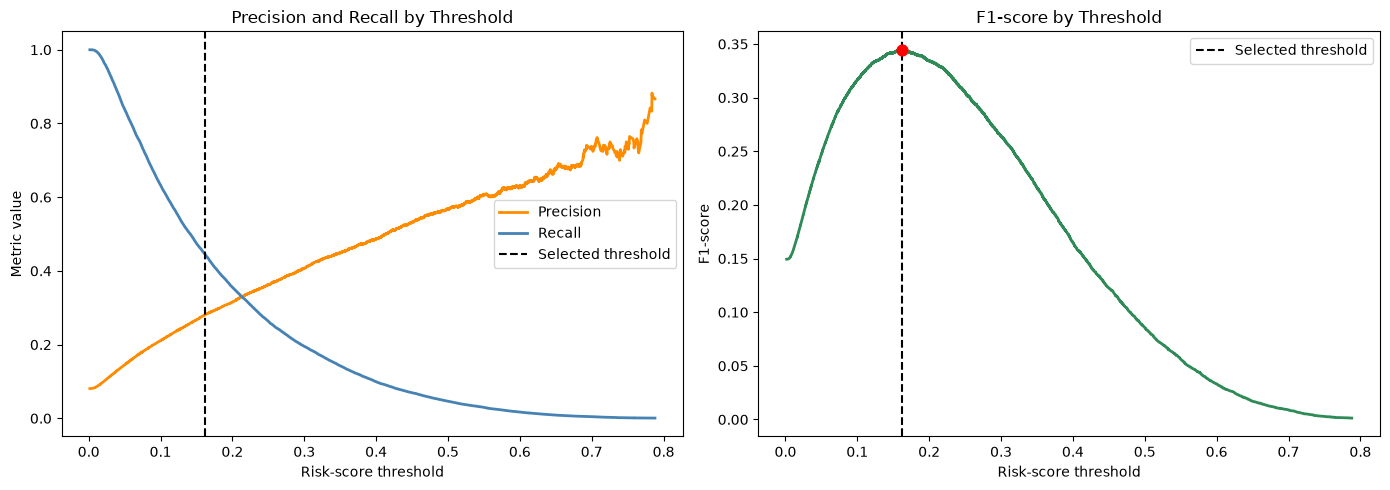

Figure saved: /Users/taranveersingh/A-MRP/reports/figures/ensemble_threshold_analysis.png


In [16]:
plot_data = threshold_analysis.loc[
    threshold_analysis["threshold"] <= 0.80
].copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    plot_data["threshold"],
    plot_data["precision"],
    label="Precision",
    color="darkorange",
    linewidth=2,
)

axes[0].plot(
    plot_data["threshold"],
    plot_data["recall"],
    label="Recall",
    color="steelblue",
    linewidth=2,
)

axes[0].axvline(
    selected_threshold,
    color="black",
    linestyle="--",
    label="Selected threshold",
)

axes[0].set_xlabel("Risk-score threshold")
axes[0].set_ylabel("Metric value")
axes[0].set_title("Precision and Recall by Threshold")
axes[0].legend()


axes[1].plot(
    plot_data["threshold"],
    plot_data["f1_score"],
    color="seagreen",
    linewidth=2,
)

axes[1].axvline(
    selected_threshold,
    color="black",
    linestyle="--",
    label="Selected threshold",
)

axes[1].scatter(
    selected_threshold,
    selected_oof_result["f1_score"],
    color="red",
    s=60,
    zorder=3,
)

axes[1].set_xlabel("Risk-score threshold")
axes[1].set_ylabel("F1-score")
axes[1].set_title("F1-score by Threshold")
axes[1].legend()

fig.tight_layout()

figure_path = (
    figure_folder
    / "ensemble_threshold_analysis.png"
)

fig.savefig(
    figure_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", figure_path)

Shows how precision, recall, and F1-score all change as the cutoff moves, and marks where the selected threshold lands. Lower cutoffs catch more defaulters but flag more false alarms; higher cutoffs do the opposite.


## Validate and save results


In [19]:
maximum_f1 = threshold_analysis[
    "f1_score"
].max()

validation_checks = pd.DataFrame([
    {
        "check": "Complete training dataset used",
        "passed": (
            len(oof_data)
            == EXPECTED_TRAINING_ROWS
        ),
    },
    {
        "check": "All five OOF folds present",
        "passed": (
            oof_data["FOLD"].nunique()
            == 5
        ),
    },
    {
        "check": "Applicant IDs are unique",
        "passed": (
            oof_data["SK_ID_CURR"].is_unique
        ),
    },
    {
        "check": "Final test set excluded",
        "passed": (
            not oof_data["SK_ID_CURR"]
            .isin(test_id_set)
            .any()
        ),
    },
    {
        "check": "Raw ensemble scores complete",
        "passed": (
            not oof_data["raw_equal_vote"]
            .isna()
            .any()
        ),
    },
    {
        "check": "Selected threshold is valid",
        "passed": (
            score.min()
            <= selected_threshold
            <= score.max()
        ),
    },
    {
        "check": "Selected threshold has maximum F1",
        "passed": np.isclose(
            selected_oof_result["f1_score"],
            maximum_f1,
        ),
    },
    {
        "check": "Threshold results are finite",
        "passed": np.isfinite(
            threshold_comparison.select_dtypes(
                include="number"
            ).to_numpy()
        ).all(),
    },
])

display(validation_checks)

assert validation_checks["passed"].all(), (
    "At least one threshold-analysis check failed."
)


selected_threshold_table = pd.DataFrame([
    selected_oof_result
])

summary = {
    "primary_score": "raw_equal_vote",
    "threshold_selection": (
        "Maximum F1-score using training OOF predictions"
    ),
    "selected_threshold": selected_threshold,
    "training_oof_precision": (
        selected_oof_result["precision"]
    ),
    "training_oof_recall": (
        selected_oof_result["recall"]
    ),
    "training_oof_f1_score": (
        selected_oof_result["f1_score"]
    ),
    "final_test_used_for_selection": False,
}


oof_data.to_pickle(
    result_folder
    / "raw_ensemble_oof_predictions.pkl"
)

oof_data.to_csv(
    result_folder
    / "raw_ensemble_oof_predictions.csv",
    index=False,
)

ranking_metrics.to_csv(
    result_folder
    / "raw_ensemble_ranking_metrics.csv",
    index=False,
)

threshold_analysis.to_csv(
    result_folder
    / "full_threshold_analysis.csv",
    index=False,
)

threshold_comparison.to_csv(
    result_folder
    / "threshold_comparison.csv",
    index=False,
)

selected_threshold_table.to_csv(
    result_folder
    / "selected_threshold.csv",
    index=False,
)

with open(
    result_folder
    / "classification_cutoff_summary.json",
    "w"
) as file:
    json.dump(
        summary,
        file,
        indent=2
    )

validation_checks.to_csv(
    audit_folder
    / "ensemble_threshold_analysis_validation.csv",
    index=False,
)

print(
    "Selected threshold:",
    round(selected_threshold, 10)
)

print(
    "Threshold-analysis results saved in:",
    result_folder
)

,check,passed
0,Complete training dataset used,True
1,All five OOF folds present,True
2,Applicant IDs are unique,True
3,Final test set excluded,True
4,Raw ensemble scores complete,True
5,Selected threshold is valid,True
6,Selected threshold has maximum F1,True
7,Threshold results are finite,True


Selected threshold: 0.1619911461
Threshold-analysis results saved in: /Users/taranveersingh/A-MRP/data/modeling/classification_cutoff_results


All checks passed. The selected threshold (0.161991) is frozen here and reused unchanged in the final test evaluation.


## Summary

The final threshold was selected using training out-of-fold predictions. The maximum F1-score was obtained at a risk-score threshold of approximately 0.162. Higher thresholds improved precision but identified fewer actual defaulters. The final test set was not used during threshold selection.